# 06 - Model Improvement Experiments

This notebook loads the trained model from notebook 05 and experiments with the **decision threshold** to improve classification performance - particularly for the forged class which is the higher-risk misclassification in a document forensics context.

**Input:** `outputs/models/stamp_resnet50_final.keras`, `outputs/roi_dataset_v3/`  
**Output:** `outputs/models/final_stamp_classifier.keras` with the optimised threshold determined here

> The model weights are not retrained in this notebook. Only the decision threshold applied to the model's output probabilities is tuned.

---
## Contents
1. Imports
2. Configuration
3. Build DataFrame
4. Recreate train / val / test split
5. Dataset loader and test dataset
6. Load trained model
7. Predict probabilities
8. Evaluate at default threshold (0.5)
9. Threshold sweep (0.10 → 0.90)
10. Best threshold by forged F1
11. Plot threshold performance
12. Final evaluation with best threshold
13. Save final model


## 1. Imports

In [20]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    f1_score,
    accuracy_score,
    precision_score,
    recall_score,
)

from tensorflow.keras.applications.resnet50 import preprocess_input

## 2. Configuration

| Variable | Value | Description |
|---|---|---|
| `ROI_DATASET_ROOT` | `../outputs/roi_dataset_v3/` | ROI images from notebook 04 |
| `MODEL_PATH` | `../outputs/models/stamp_resnet50_final.keras` | Trained model from notebook 05 |
| `IMG_SIZE` | 224 | Input image size — must match training |
| `BATCH_SIZE` | 16 | Batch size for prediction |
| `SEED` | 42 | Random seed — must match notebook 05 to reproduce the same split |


In [21]:
ROI_DATASET_ROOT = Path("../outputs/roi_dataset_v3")

GENUINE_DIR = ROI_DATASET_ROOT / "genuine"
FORGED_DIR = ROI_DATASET_ROOT / "forged"

MODEL_PATH = Path("../outputs/models/stamp_resnet50_final.keras")

IMG_SIZE = 224
BATCH_SIZE = 16
SEED = 42

## 3. Build DataFrame

Rebuilds the image path DataFrame from the ROI dataset. 


In [23]:
records = []

for path in GENUINE_DIR.rglob("*.png"):
    records.append({"image_path": str(path), "label": 0, "class_name": "genuine"})

for path in FORGED_DIR.rglob("*.png"):
    records.append({"image_path": str(path), "label": 1, "class_name": "forged"})

df = pd.DataFrame(records)

print("Total images:", len(df))
print(df["class_name"].value_counts())

Total images: 458
class_name
genuine    313
forged     145
Name: count, dtype: int64


## 4. Recreate Train / Val / Test Split

Recreates the exact same 70/15/15 split using the`SEED=42` and `stratify` settings. This is critical - using a different split would mean evaluating on images the model was trained on, giving misleadingly high results.


In [31]:
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df["label"], random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label"], random_state=SEED
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print("\nTest distribution:")
print(test_df["class_name"].value_counts())

Train: 320
Validation: 69
Test: 69

Test distribution:
class_name
genuine    47
forged     22
Name: count, dtype: int64


## 5. Dataset Loader - `load_and_preprocess_image`

Same image loading and preprocessing function. Reads each PNG, resizes to 224×224, and applies ResNet50 normalisation via `preprocess_input`.


In [32]:
def load_and_preprocess_image(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = preprocess_input(image)
    return image, label

## 6. Create Test Dataset

Builds a `tf.data` pipeline for the test set only. No shuffling is applied since this is evaluation - the order must be consistent with `y_true = test_df["label"].values`.


In [33]:
def create_dataset(dataframe):
    image_paths = dataframe["image_path"].values
    labels = dataframe["label"].values

    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))

    dataset = dataset.map(
        load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE
    )

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset


test_ds = create_dataset(test_df)

## 7. Load Trained Model

Loads the fully trained ResNet50 model saved by notebook 05. The model outputs a single sigmoid probability per image - the probability that the stamp is forged (class 1).


In [34]:
model = tf.keras.models.load_model(MODEL_PATH)

print("Model loaded successfully")

Model loaded successfully


## 8. Predict Probabilities

Runs the model on the entire test set and stores the raw output probabilities in `y_prob`. These are continuous values between 0 and 1 - not yet converted to class labels.

Storing the raw probabilities allows testing multiple decision thresholds without re-running the model each time.


In [35]:
y_true = test_df["label"].values

y_prob = model.predict(test_ds).ravel()

print("Prediction probabilities shape:", y_prob.shape)
print("First 10 probabilities:")
print(y_prob[:10])

5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step
Prediction probabilities shape: (69,)
First 10 probabilities:
[0.4792144  0.49728757 0.5583738  0.62367404 0.44954526 0.40289876
 0.31020585 0.64604634 0.48509717 0.5792054 ]


## 9. Evaluate at Default Threshold (0.5)

Applies the standard 0.5 threshold - a probability ≥ 0.5 is classified as forged, anything below as genuine. Prints the classification report and confusion matrix as the baseline to compare against.

This is the starting point. The threshold sweep below will determine if a different threshold improves performance on the forged class.


              precision    recall  f1-score   support

     genuine       0.67      0.51      0.58        47
      forged       0.30      0.45      0.36        22

    accuracy                           0.49        69
   macro avg       0.48      0.48      0.47        69
weighted avg       0.55      0.49      0.51        69



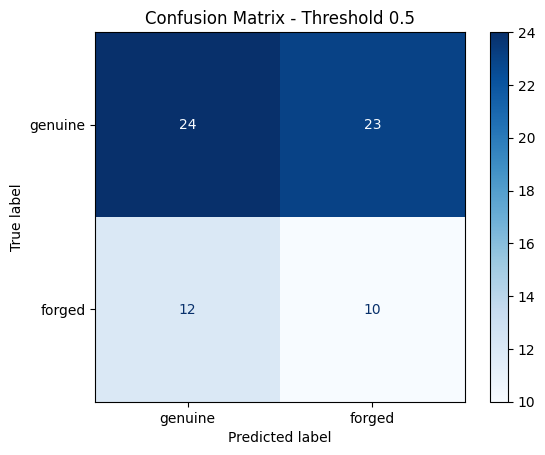

In [36]:
threshold = 0.5

y_pred_05 = (y_prob >= threshold).astype(int)

print(classification_report(y_true, y_pred_05, target_names=["genuine", "forged"]))

cm = confusion_matrix(y_true, y_pred_05)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["genuine", "forged"])

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Threshold 0.5")
plt.show()

## 10. Threshold Sweep (0.10 → 0.90)

Tests 17 thresholds between 0.10 and 0.90 in steps of 0.05. For each threshold, calculates accuracy, forged precision, forged recall, forged F1, and the full confusion matrix breakdown.

**Why sweep thresholds?**
The default 0.5 threshold assumes equal cost for false positives and false negatives. In document forensics, a missed forgery (false negative - forged classified as genuine) is a higher-risk error than a false alarm (false positive - genuine classified as forged). Lowering the threshold increases forged recall at the cost of some precision - catching more forgeries while accepting more false alarms.

Results are stored in `df_thresholds` for comparison.


In [37]:
thresholds = np.arange(0.10, 0.91, 0.05)

results = []

for threshold in thresholds:
    y_pred = (y_prob >= threshold).astype(int)

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    results.append(
        {
            "threshold": threshold,
            "accuracy": accuracy,
            "forged_precision": precision,
            "forged_recall": recall,
            "forged_f1": f1,
            "true_genuine": tn,
            "false_forged": fp,
            "missed_forged": fn,
            "true_forged": tp,
        }
    )

df_thresholds = pd.DataFrame(results)

df_thresholds

,threshold,accuracy,forged_precision,forged_recall,forged_f1,true_genuine,false_forged,missed_forged,true_forged
0,0.10,0.318841,0.318841,1.000000,0.483516,0,47,0,22
1,0.15,0.318841,0.318841,1.000000,0.483516,0,47,0,22
2,0.20,0.318841,0.318841,1.000000,0.483516,0,47,0,22
3,0.25,0.304348,0.308824,0.954545,0.466667,0,47,1,21
4,0.30,0.333333,0.318182,0.954545,0.477273,2,45,1,21
5,0.35,0.362319,0.322581,0.909091,0.476190,5,42,2,20
6,0.40,0.362319,0.303571,0.772727,0.435897,8,39,5,17
7,0.45,0.434783,0.311111,0.636364,0.417910,16,31,8,14
8,0.50,0.492754,0.303030,0.454545,0.363636,24,23,12,10
9,0.55,0.536232,0.291667,0.318182,0.304348,30,17,15,7


## 11. Best Threshold by Forged F1

Selects the threshold that produces the highest forged F1-score from `df_thresholds`. F1 balances precision and recall - so this threshold gives the best overall performance on the forged class without sacrificing too much precision.

The selected `best_threshold` is used in the final evaluation below and hardcoded into notebook 07 as `BEST_THRESHOLD`.


In [38]:
best_row = df_thresholds.sort_values("forged_f1", ascending=False).iloc[0]

best_threshold = best_row["threshold"]

print("Best threshold based on forged F1:")
print(best_row)

Best threshold based on forged F1:
threshold            0.100000
accuracy             0.318841
forged_precision     0.318841
forged_recall        1.000000
forged_f1            0.483516
true_genuine         0.000000
false_forged        47.000000
missed_forged        0.000000
true_forged         22.000000
Name: 0, dtype: float64


## 12. Plot Threshold Performance

Plots accuracy, forged precision, forged recall, and forged F1 across all tested thresholds on a single chart.

**What to look for:**
- As threshold decreases, recall rises (more forgeries caught) but precision drops (more false alarms)
- As threshold increases, precision rises but recall drops (more forgeries missed)
- The best threshold sits at the point where F1 peaks — the best balance between the two


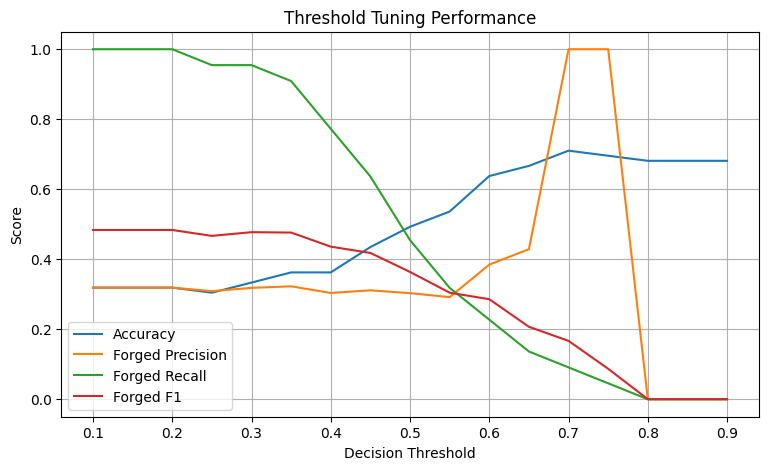

In [39]:
plt.figure(figsize=(9, 5))
plt.plot(df_thresholds["threshold"], df_thresholds["accuracy"], label="Accuracy")
plt.plot(
    df_thresholds["threshold"],
    df_thresholds["forged_precision"],
    label="Forged Precision",
)
plt.plot(
    df_thresholds["threshold"], df_thresholds["forged_recall"], label="Forged Recall"
)
plt.plot(df_thresholds["threshold"], df_thresholds["forged_f1"], label="Forged F1")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Threshold Tuning Performance")
plt.legend()
plt.grid(True)
plt.show()

## 13. Final Evaluation with Best Threshold

Re-evaluates the model on the test set using `best_threshold` instead of 0.5. Prints the full classification report and confusion matrix. Compare these results against the baseline (0.5 threshold) evaluation above to confirm the improvement.


Best threshold: 0.1
              precision    recall  f1-score   support

     genuine       0.00      0.00      0.00        47
      forged       0.32      1.00      0.48        22

    accuracy                           0.32        69
   macro avg       0.16      0.50      0.24        69
weighted avg       0.10      0.32      0.15        69



D:\OneDrive - engug.ruh.ac.lk\2. Semester 7\EC7205 - IMAGE PROCESSING AND COMPUTER VISION\1. Project\forged-stamp-recognizer\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\OneDrive - engug.ruh.ac.lk\2. Semester 7\EC7205 - IMAGE PROCESSING AND COMPUTER VISION\1. Project\forged-stamp-recognizer\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\OneDrive - engug.ruh.ac.lk\2. Semester 7\EC7205 - IMAGE PROCESSING AND COMPUTER VISION\1. Project\forged-stamp-recognizer\.venv\Lib\site-

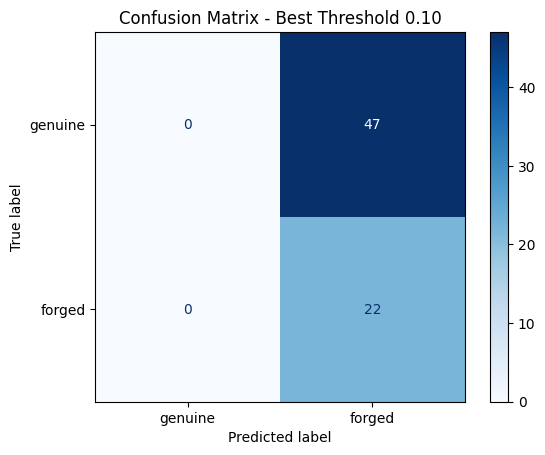

In [40]:
y_pred_best = (y_prob >= best_threshold).astype(int)

print("Best threshold:", best_threshold)

print(classification_report(y_true, y_pred_best, target_names=["genuine", "forged"]))

cm = confusion_matrix(y_true, y_pred_best)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["genuine", "forged"])

disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix - Best Threshold {best_threshold:.2f}")
plt.show()

## 14. Save Final Model

Saves the model to `outputs/models/final_stamp_classifier.keras`. This is the model used by notebook 07 for inference, combined with `BEST_THRESHOLD` determined above.


In [41]:
FINAL_MODEL_PATH = "../outputs/models/final_stamp_classifier.keras"

model.save(FINAL_MODEL_PATH)

print("Final model saved:", FINAL_MODEL_PATH)

Final model saved: ../outputs/models/final_stamp_classifier.keras
